### (b) Bias DeepLDA

## Setup

In [11]:
import os
import subprocess
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plumed

In [ ]:
# Configurations
BASE_DIR    = Path("/home/dani/wslcoding/MCFM/ML-CV")
INPUT_DIR   = BASE_DIR / "input"
MD_IN_DIR   = INPUT_DIR / "md_inputs"
DATA_DIR    = BASE_DIR / "data"
GMX_CMD     = "gmx_mpi"  # I compiled gromacs with mpi support
TEST_NUM_STEPS   = 10_000     # for testing  
NUM_STEPS   = 500_000    # productions
NUM_STEPS   = 2_500_000
STRIDE      = 500

num_steps   = NUM_STEPS
test_num_steps = TEST_NUM_STEPS

os.chdir(BASE_DIR)

In [3]:
# Check working directory
os.getcwd()

'/home/dani/wslcoding/MCFM/ML-CV'

In [4]:
# helper functions

# delete outputs of simulations from `folder``
def clean(folder='./'):
    subprocess.run("rm -f bck.* COLVAR KERNELS alanine.* \\#*\\# alanine_prev.cpt", cwd=folder, shell=True)

# execute bash command in the given folder
def execute(command, folder, background=False):
    cmd = subprocess.run(command, cwd=folder, shell=True, capture_output = True, text=True, close_fds=background)
    if cmd.returncode == 0:
        print(f'Completed: {command}')
    else:
        print(cmd.stderr)

### copy data files and create plumed.dat

In [5]:
folder = DATA_DIR / "1_meta-deeplda/"
execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folder)
execute(f"cp {MD_IN_DIR}/input.tpr .", folder)

Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .


In [6]:
# WRITE PLUMED INPUT FILE
with open(folder / "plumed.dat", "w") as f:
    f.write(f"""\
# vim:ft=plumed

# Compute torsion angles, as well as energy
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
theta: TORSION ATOMS=6,5,7,9
xi: TORSION ATOMS=16,15,17,19
ene: ENERGY

# Compute descriptors
INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

# Compute DeepLDA CV
deep: PYTORCH_MODEL FILE=model.ptc    ARG=d_2_5,d_2_6,d_2_7,d_2_9,d_2_11,d_2_15,d_2_16,d_2_17,d_2_19,d_5_6,d_5_7,d_5_9,d_5_11,d_5_15,d_5_16,d_5_17,d_5_19,d_6_7,d_6_9,d_6_11,d_6_15,d_6_16,d_6_17,d_6_19,d_7_9,d_7_11,d_7_15,d_7_16,d_7_17,d_7_19,d_9_11,d_9_15,d_9_16,d_9_17,d_9_19,d_11_15,d_11_16,d_11_17,d_11_19,d_15_16,d_15_17,d_15_19,d_16_17,d_16_19,d_17_19

metad: METAD ARG=deep.node-0 ...
   # Deposit a Gaussian every 500 time steps, with initial height 
   # equal to 1.2 kJ/mol and bias factor equal to 8 
   PACE=500 HEIGHT=1.2 BIASFACTOR=8 
   # Gaussian width (sigma) should be chosen based on the CV fluctuations in unbiased run 
   SIGMA=0.3 
   # Gaussians will be written to file and also stored on grid 
   FILE=HILLS GRID_MIN=-pi GRID_MAX=pi 
...

# Print 
PRINT FMT=%g STRIDE={STRIDE} FILE=COLVAR ARG=*
ENDPLUMED
""")

In [8]:
clean(folder) # note: this deletes all previous results in folder!

In [10]:
# RUN GROMACS

execute(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps {test_num_steps} > alanine.out", folder=folder)

Completed: gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps 10000 > alanine.out


In [17]:
# print command to run in terminal (for longer run)

print(f"cd {folder}")
print(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps {num_steps} -v")

cd /home/dani/wslcoding/MCFM/ML-CV/data/1_meta-deeplda
gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps 500000 -v


Once the simulation is over, we can plot the time evolution of the Deep-LDA CV, in which several transitions between the states A and B (-1 and 1) can be observed. Furthermore, we can look at the Ramachandran plot to see the explored region.

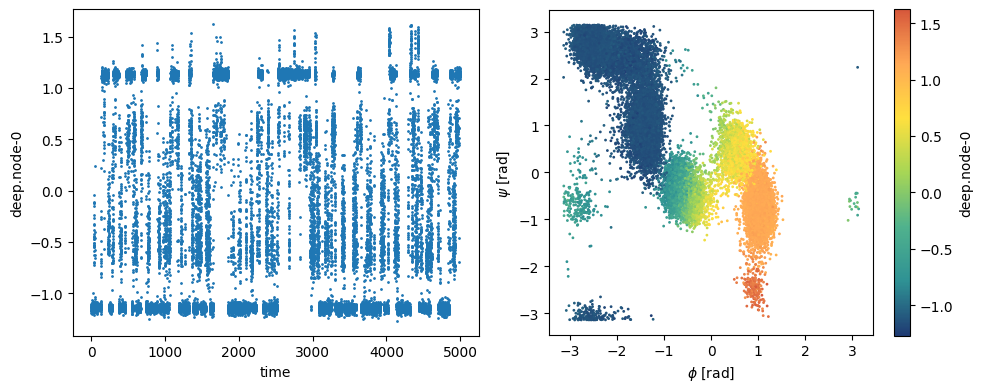

In [24]:
import mlcolvar.utils.plot
from mlcolvar.utils.io import load_dataframe
colvar = load_dataframe(f"{folder}/COLVAR")

fig,axs = plt.subplots(1,2,figsize=(10,4),dpi=100)
# Time evolution (DeepLDA)
colvar.plot.scatter('time','deep.node-0',s=1,ax=axs[0])
axs[1].set_xlabel('Time [ps]')
axs[1].set_xlabel('DeepLDA')
# 2D scatter plot colored with DeepLDA
colvar.plot.scatter('phi','psi',c='deep.node-0',s=1,cmap='fessa',ax=axs[1])
axs[1].set_xlabel(r'$\phi$ [rad]')
axs[1].set_ylabel(r'$\psi$ [rad]')
axs[1].set_aspect('equal')

plt.tight_layout()
plt.show()

In [25]:
colvar.head()

,time,phi,psi,theta,xi,ene,d_2_5,d_2_6,d_2_7,d_2_9,...,d_11_19,d_15_16,d_15_17,d_15_19,d_16_17,d_16_19,d_17_19,deep.node-0,metad.bias,walker
0,0.0,-2.36867,2.64432,-0.202258,0.048056,-41.45830,0.152064,0.233505,0.241173,0.379827,...,0.452694,0.126976,0.130073,0.244001,0.227324,0.281913,0.148169,-1.13657,0.0,0
1,0.2,-2.01898,2.09469,0.183210,-0.178198,-26.62960,0.155184,0.240710,0.248149,0.389691,...,0.475079,0.123270,0.131440,0.242846,0.224891,0.277797,0.147679,-1.11136,0.0,0
2,0.4,-1.13139,2.51985,-0.281659,0.294618,-2.19324,0.153063,0.234471,0.243033,0.374476,...,0.473166,0.118082,0.137847,0.252739,0.232262,0.299266,0.149680,-1.16755,0.0,0
3,0.6,-1.64721,2.11314,0.231530,-0.183816,-15.40100,0.159816,0.246010,0.253918,0.392053,...,0.482696,0.119017,0.136940,0.255319,0.226818,0.292098,0.151715,-1.17597,0.0,0
4,0.8,-1.69177,2.11845,-0.329666,0.034495,-10.47410,0.149143,0.235045,0.235169,0.376047,...,0.474980,0.125090,0.132779,0.237819,0.225958,0.269223,0.143853,-1.13440,0.0,0


(0.0, 50.0)

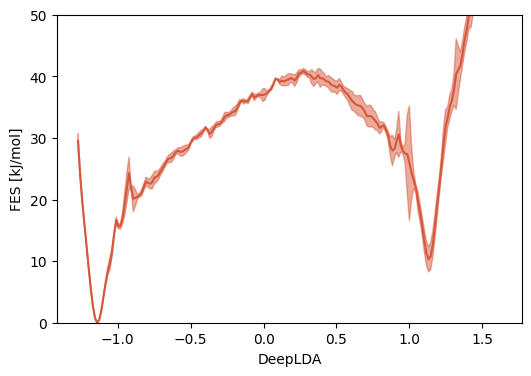

In [26]:
from mlcolvar.utils.fes import compute_fes

s = colvar['deep.node-0'].values

# compute weights
kbT = 2.5
w = np.exp(colvar['metad.bias'].values/kbT)

fig,ax = plt.subplots(figsize=(6,4),dpi=100)
fes,grid,bounds,error = compute_fes(s, weights=w, kbt=kbT, 
                                    blocks=5, bandwidth=0.01, 
                                    plot=True, ax = ax)
ax.set_xlabel('DeepLDA')
ax.set_ylabel('FES [kJ/mol]')
ax.set_ylim(0,50)